In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data=pd.read_csv('Students Social Media Addiction.csv')
data

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


## Column Descriptions (Features)

| Column Name                       | Type        | Description                           |
| ---------------------------------- | ----------- | ------------------------------------- |
| **Student\_ID**                    | Integer     | A unique identifier assigned to each student.|
| **Age**                            | Integer     | The student’s age in years.|
| **Gender**                         | Categorical | Gender of the student.|
| **Academic\_Level**                | Categorical | The current level of academic study (e.g., Undergraduate, Postgraduate)|
| **Country**                        | Categorical | The country of residence of the student.|
| **Avg\_Daily\_Usage\_Hours**       | Float       | Average number of hours per day the student spends on social media.|
| **Most\_Used\_Platform**           | Categorical | The primary social media platform used by the student (e.g., Instagram, TikTok)|
| **Affects\_Academic\_Performance** | Categorical | Indicates whether the student believes social media has a negative impact on their academic performance.|
| **Sleep\_Hours\_Per\_Night**       | Float       | Average number of hours the student sleeps per night.|
| **Mental\_Health\_Score**          | Integer     | A numerical score indicating the student's mental well-being. Ranges typically from 0 (poor) to 10 (excellent).|
| **Relationship\_Status**           | Categorical | Whether the student is single, in a relationship, or in complicated relationships.|
| **Conflicts\_Over\_Social\_Media** | Integer     | Number of times the student has had arguments or issues with others due to social media use.|
| **Addicted\_Score**                | Integer     | A score from 1 to 10 representing the level of social media addiction. Higher values indicate stronger addiction. |

## Basic Information

In [77]:
data.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

In [78]:
# number of countries in the dataset
data.get('Country').describe()

count       705
unique      110
top       India
freq         53
Name: Country, dtype: object

(array([ 0., 10., 20., 30., 40., 50., 60.]),
 [Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60')])

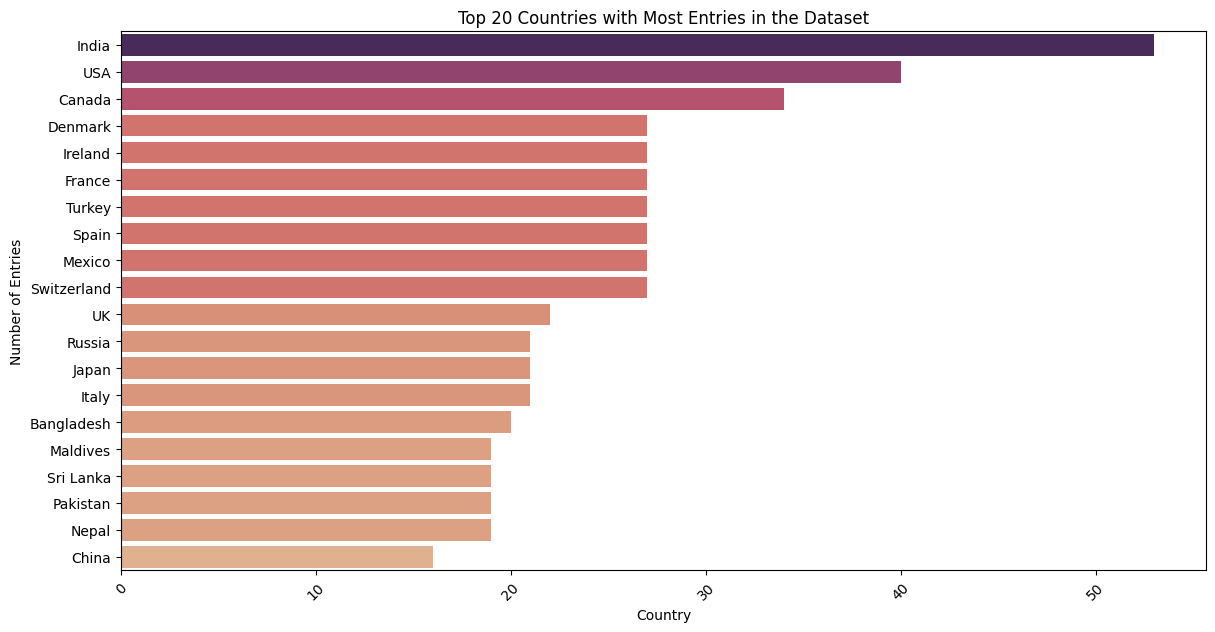

In [79]:
# Top 20 countries with the most entries in the dataset
top_20=data.groupby('Country').size().sort_values(ascending=False).head(20).sort_values(ascending=False)
plt.figure(figsize=(14, 7))
sns.barplot(x=top_20.values, y=top_20.index, palette='flare', hue=top_20.values, legend=False)
plt.title('Top 20 Countries with Most Entries in the Dataset')
plt.xlabel('Country')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)

<Axes: title={'center': 'Distribution of Gender'}>

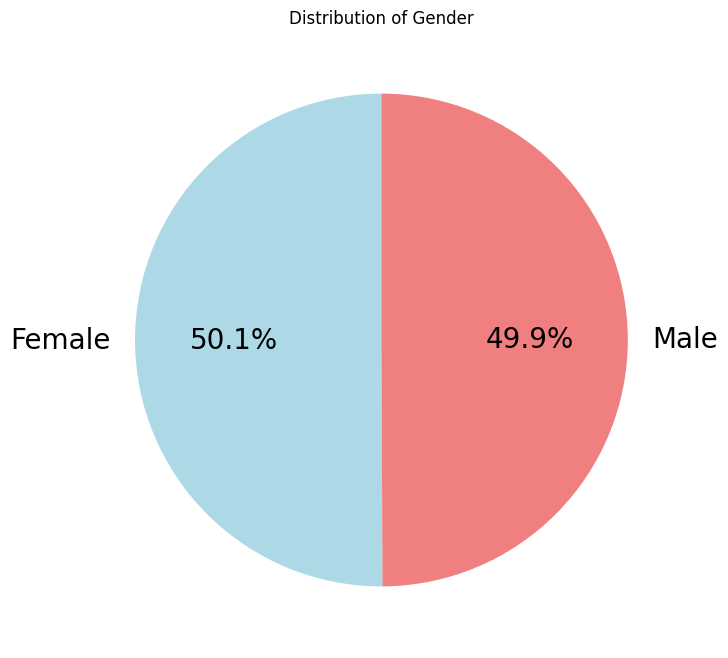

In [80]:
# distribution of gender in the dataset
data.groupby('Gender').size().plot(kind='pie', autopct='%1.1f%%', startangle=90,
    title='Distribution of Gender', figsize=(8, 8), colors=['lightblue', 'lightcoral'], fontsize=20)

<Axes: title={'center': 'Distribution of Academic Level'}>

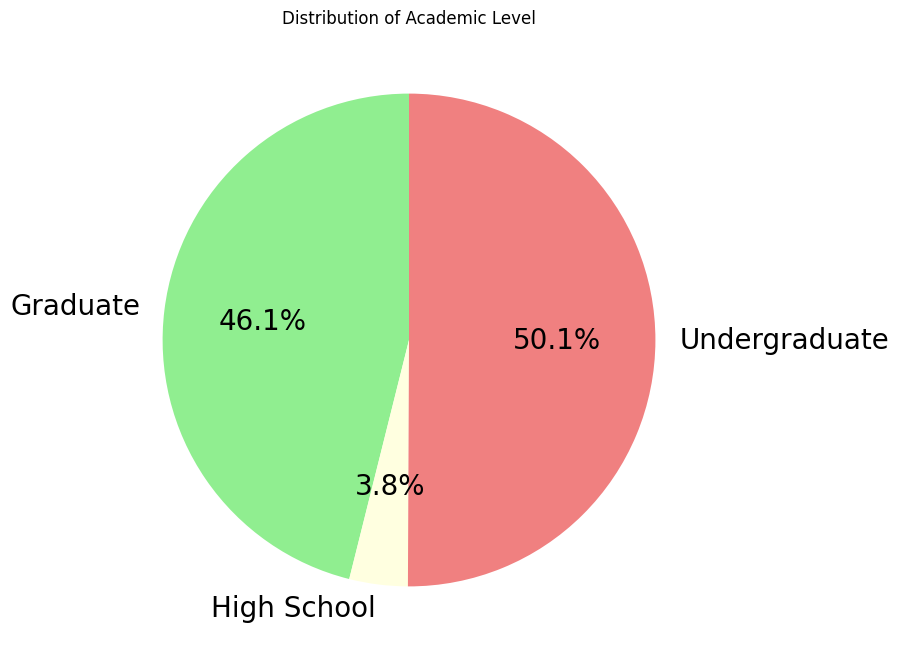

In [81]:
# distribution of Academic_Level in the dataset
data.groupby('Academic_Level').size().plot(kind='pie', autopct='%1.1f%%', startangle=90, title='Distribution of Academic Level', figsize=(8, 8), colors=['lightgreen', 'lightyellow', 'lightcoral'], fontsize=20)

Age
18     14
19    163
20    165
21    156
22    147
23     34
24     26
dtype: int64

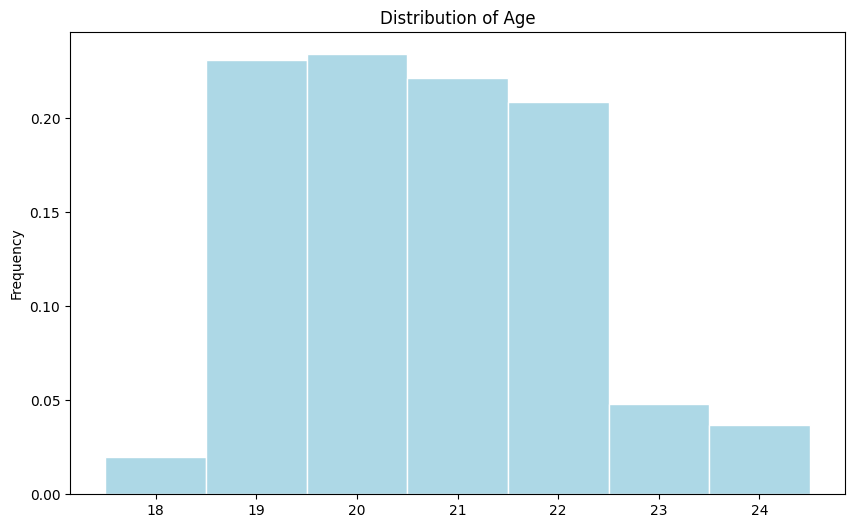

In [82]:
# distribution of age in the dataset
data.get('Age').plot(kind='hist', bins=np.arange(17.5,25.5,1), title='Distribution of Age', figsize=(10, 6), ec='w',color='lightblue',density=True)
data.groupby('Age').size()

<Axes: title={'center': 'Distribution of Addiction Score'}, ylabel='Frequency'>

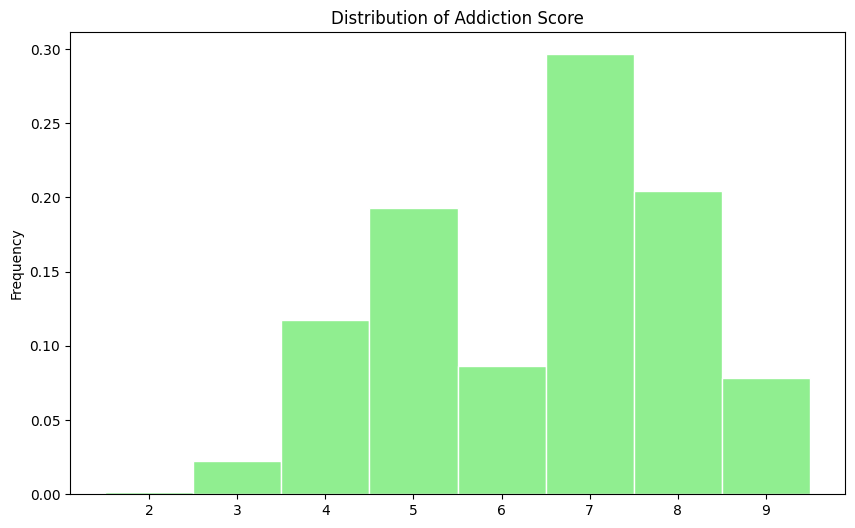

In [83]:
# distribution of addicted score in the dataset
data.get('Addicted_Score').plot(kind='hist', bins=np.arange(1.5, 10.5, 1), title='Distribution of Addiction Score', figsize=(10, 6), ec='w', color='lightgreen', density=True)

## Exploratory Data Analysis (EDA)

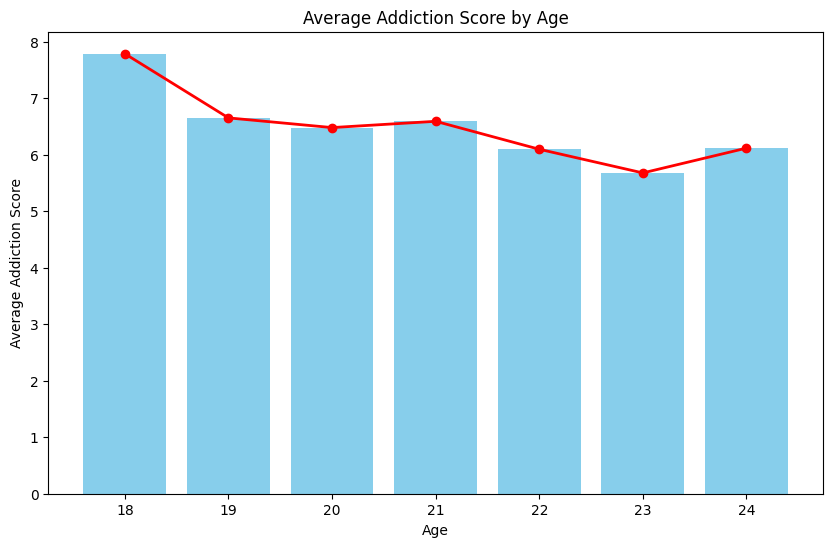

In [84]:
avg_addiction_by_age = data.groupby('Age').mean(numeric_only=True).get('Addicted_Score')
plt.figure(figsize=(10, 6))
plt.bar(avg_addiction_by_age.index, avg_addiction_by_age.values, color='skyblue')
plt.plot(avg_addiction_by_age.index, avg_addiction_by_age.values, color='red', marker='o', linestyle='-', linewidth=2)
plt.title('Average Addiction Score by Age')
plt.xlabel('Age')
plt.ylabel('Average Addiction Score')
plt.show()

In [85]:
data.groupby('Relationship_Status').mean(numeric_only=True).get('Addicted_Score').sort_values(ascending=False)

Relationship_Status
Complicated        7.031250
Single             6.458333
In Relationship    6.342561
Name: Addicted_Score, dtype: float64

In [86]:
# Pivot table: average 'Addicted_Score' by 'Academic_Level' and 'Gender'
pivot_table_addiction = data.pivot_table(values='Addicted_Score', index='Academic_Level', columns='Gender', aggfunc='mean')
print("\nPivot Table: Average Addiction Score by Academic Level and Gender:")
pivot_table_addiction


Pivot Table: Average Addiction Score by Academic Level and Gender:


Gender,Female,Male
Academic_Level,,
Graduate,6.104167,6.267148
High School,8.466667,7.500000
Undergraduate,6.482759,6.539683


Text(0, 0.5, 'Number')

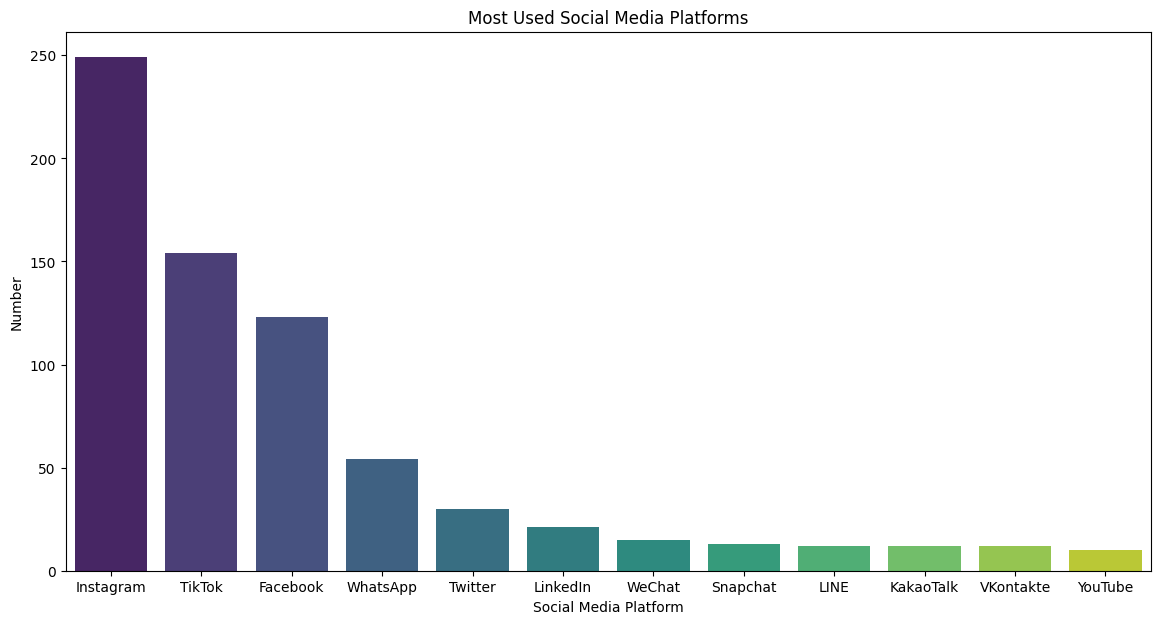

In [87]:
# most used social media platforms
platforms = data.groupby('Most_Used_Platform').size().sort_values(ascending=False)
plt.figure(figsize=(14, 7))
sns.barplot(x=platforms.index, y=platforms.values, palette='viridis', hue=platforms.index, legend=False)
plt.title('Most Used Social Media Platforms')
plt.xlabel('Social Media Platform')
plt.ylabel('Number')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'USA'),
  Text(1, 0, 'Mexico'),
  Text(2, 0, 'India'),
  Text(3, 0, 'UK'),
  Text(4, 0, 'Turkey'),
  Text(5, 0, 'Russia'),
  Text(6, 0, 'Nepal'),
  Text(7, 0, 'Spain'),
  Text(8, 0, 'Italy'),
  Text(9, 0, 'China'),
  Text(10, 0, 'Sri Lanka'),
  Text(11, 0, 'Bangladesh'),
  Text(12, 0, 'Canada'),
  Text(13, 0, 'Ireland'),
  Text(14, 0, 'Maldives'),
  Text(15, 0, 'Pakistan'),
  Text(16, 0, 'France'),
  Text(17, 0, 'Japan'),
  Text(18, 0, 'Denmark'),
  Text(19, 0, 'Switzerland')])

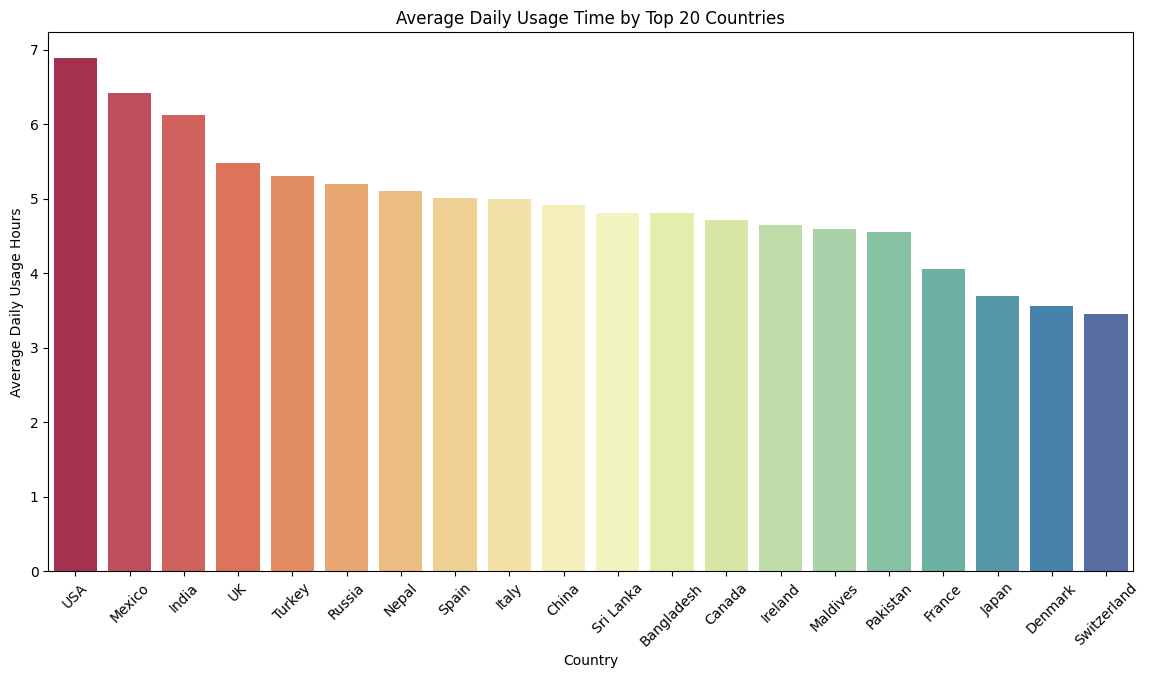

In [88]:
# avg daily usage time by top 20 countries
top_20_countries = data.groupby('Country').size().sort_values(ascending=False).head(20).index
avg_usage_by_country = data.groupby('Country').mean(numeric_only=True).get('Avg_Daily_Usage_Hours')[top_20_countries].sort_values(ascending=False)
plt.figure(figsize=(14, 7))
sns.barplot(x=avg_usage_by_country.index, y=avg_usage_by_country.values, palette='Spectral',hue=avg_usage_by_country.index,legend=False)
plt.title('Average Daily Usage Time by Top 20 Countries')
plt.xlabel('Country')
plt.ylabel('Average Daily Usage Hours')
plt.xticks(rotation=45)


Text(0.7, 0.8, 'Correlation: -0.79')

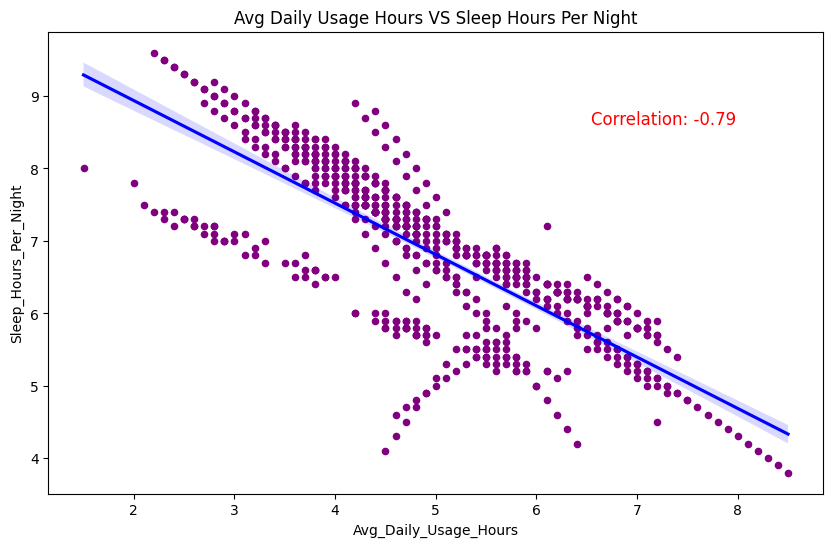

In [89]:
# Avg Daily Usage Hours VS Sleep Hours Per Night
data.plot(kind='scatter', x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night', title='Avg Daily Usage Hours VS Sleep Hours Per Night', figsize=(10, 6), color='purple')
# Adding a regression line to the scatter plot
sns.regplot(x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night', data=data, scatter=False, color='blue')
correlation = data['Avg_Daily_Usage_Hours'].corr(data['Sleep_Hours_Per_Night'])
plt.text(0.7, 0.8, f'Correlation: {correlation:.2f}', transform=plt.gca().transAxes, fontsize=12, color='red')

Text(0.7, 0.8, 'Correlation: -0.80')

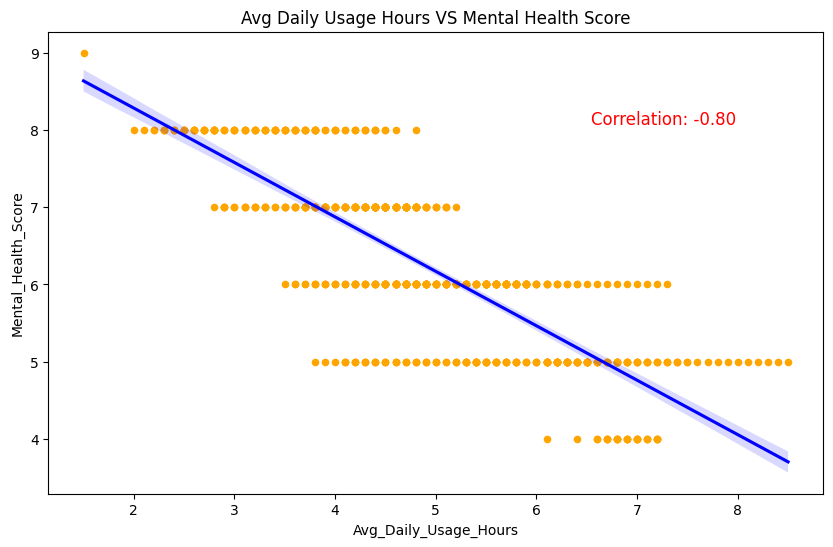

In [90]:
# Avg Daily Usage Hours VS Mental Health Score
data.plot(kind='scatter', x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', title='Avg Daily Usage Hours VS Mental Health Score', figsize=(10, 6), color='orange')
# Adding a regression line to the scatter plot
sns.regplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=data, scatter=False, color='blue')
correlation = data['Avg_Daily_Usage_Hours'].corr(data['Mental_Health_Score'])
plt.text(0.7, 0.8, f'Correlation: {correlation:.2f}', transform=plt.gca().transAxes, fontsize=12, color='red')

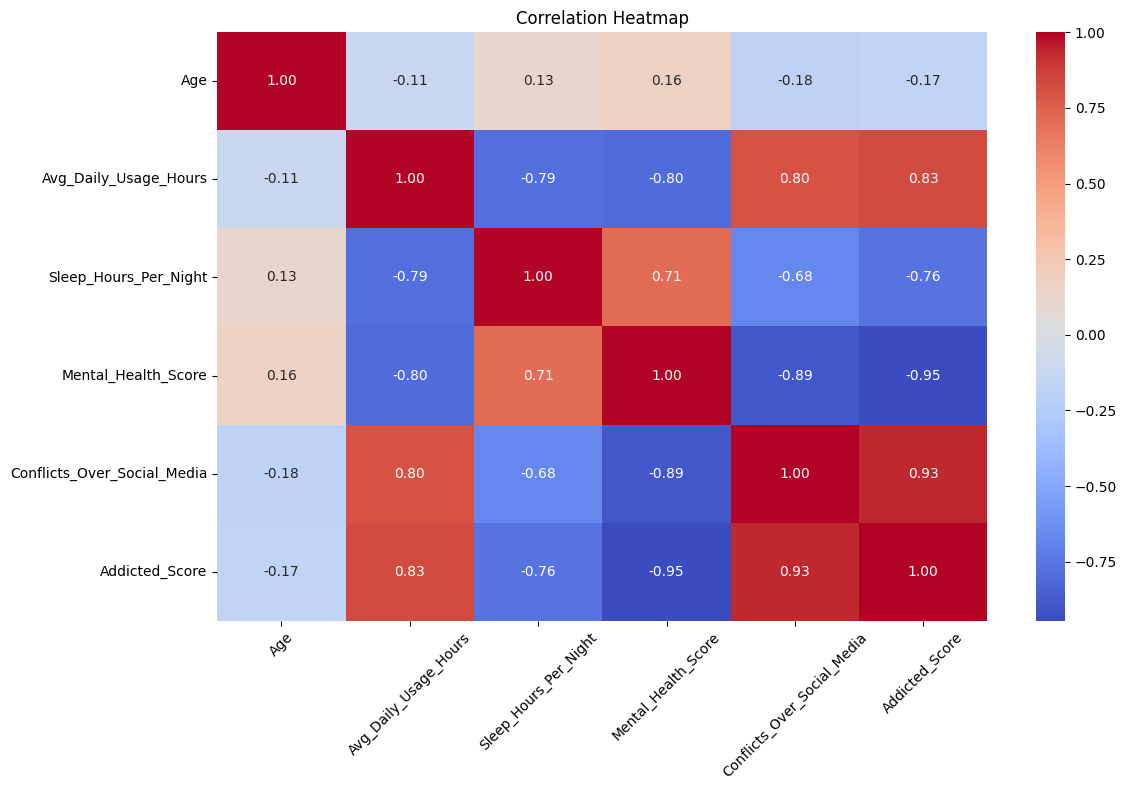

In [91]:
# heatmap of addiction score
numeric_columns = [
    "Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night",
    "Mental_Health_Score", "Conflicts_Over_Social_Media", "Addicted_Score"
]
correlation_matrix = data[numeric_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Hypothesis Testing

### 1.Academic Performance and Social Media Usage Hours

- **Null hypothesis**:  There is no difference between the two groups (academic performance affected vs. not affected) in terms of average social media usage hours.
    - In other words, the difference we saw was due to random chance.
- **Alternative hypothesis**:  There is a significant difference in average social media usage between students whose academic performance is affected and those whose isn't. 
    - In other words, what we saw cannot be explained by random chance alone, and there is instead a meaningful difference in these distributions.

**Overview of the data**

In [92]:
dailyuse_and_academic_performance = data[['Avg_Daily_Usage_Hours', 'Affects_Academic_Performance']]
dailyuse_and_academic_performance

,Avg_Daily_Usage_Hours,Affects_Academic_Performance
0,5.2,Yes
1,2.1,No
2,6.0,Yes
3,3.0,No
4,4.5,Yes
...,...,...
700,4.7,No
701,6.8,Yes
702,5.6,Yes
703,4.3,No


**Test statistic: the difference between means**

In [93]:
means_table= dailyuse_and_academic_performance.groupby('Affects_Academic_Performance').mean()
means = means_table.get('Avg_Daily_Usage_Hours')
observed_difference = means.loc['Yes'] - means.loc['No']
observed_difference

np.float64(1.734266267213287)

**Permutation Test(Simulation)**
- We have to repeat the shuffling a bunch of times. On each iteration:
    1. Shuffle the average daily social media usage hour.
    2. Put them in a DataFrame.
    3. Compute the difference in group means.

In [94]:
def difference_in_mean_usage_hour(hours_df):
    group_means = hours_df.groupby('Affects_Academic_Performance').mean().get('Shuffled_Avg_Daily_Usage_Hours')
    return group_means.loc['Yes'] - group_means.loc['No']

In [95]:
n_repetitions = 5000 

differences = np.array([])
for i in np.arange(n_repetitions):
    # Step 1: Shuffle
    shuffled_hours = np.random.permutation(
        dailyuse_and_academic_performance.get('Avg_Daily_Usage_Hours')
    )
    
    # Step 2: Put them in a DataFrame
    shuffled = dailyuse_and_academic_performance.assign(
        Shuffled_Avg_Daily_Usage_Hours=shuffled_hours
    )
    
    # Step 3: Compute the difference in group means and add the result to the differences array
    difference = difference_in_mean_usage_hour(shuffled)
    
    differences = np.append(differences, difference)

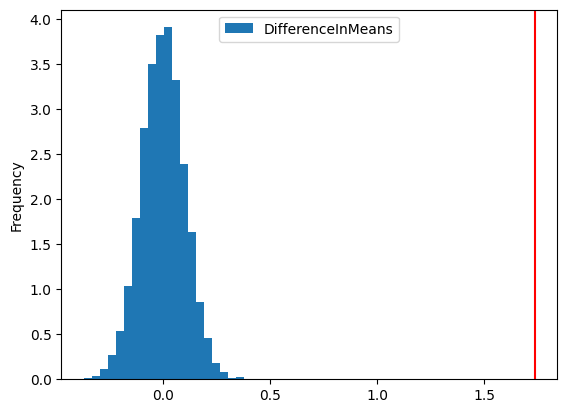

In [96]:
pd.DataFrame().assign(DifferenceInMeans=differences).plot(kind='hist', bins=20, density=True)
plt.axvline(observed_difference, color='red');

**Conclusion**

- Under the null hypothesis, we rarely see differences as large as this.
- Therefore, we reject the null hypothesis: the two groups do not come from the same distribution.
- That is to say, there may be meaningful relationship between average daily social media usage time and academic performance.

### Relationship and Addiction Score

In [97]:
data.groupby('Relationship_Status').mean(numeric_only=True).get('Addicted_Score').sort_values(ascending=False)

Relationship_Status
Complicated        7.031250
Single             6.458333
In Relationship    6.342561
Name: Addicted_Score, dtype: float64

We notice a high addicted score of complicated relationship status compared to single or in relationship.
Since single and in relationship have similar addicted scores, we combine them into one category for further analysis, i.e. Simple.

H_0: There is no significant difference in the addicted score between students in complicated relationships and those in simple relationships.  
H_1: There is a significant increase in the addicted score for students in complicated relationships than those in simple relationships.

First we perform an F-test to compare the variances of the addicted scores between the two groups (Complicated vs. Simple).  
H_0: The variances of the addicted scores in both groups are equal.  
H_1: The variances of the addicted scores in both groups are not equal.

<center><img src="F-Test.png" alt="F-Test Result" width="600"></center>

Based on the F-test result, 0.43270586 >> 0.05, we fail to reject the null hypothesis (H_0). This suggests that there is no significant difference in Variance of the addicted score between students in complicated relationships and those in simple relationships.

Since the samples are relatively large ( >30 ), according to Central Limit Theorm, the distribution is close to nomral distribution. Therefore we use a t-Test: Two-Sample Assuming Equal Variances to compare the means of the addicted scores between the two groups (Complicated vs. Simple).

<center><img src="t-Test.png" alt="F-Test Result" width="600"></center>

Since the p-value (0.015022067) is less than the significance level (0.05), we reject the null hypothesis (H_0). This suggests that there is a significant increase in the addicted score for students in complicated relationships than those in simple relationships.

## Predictive Model

### Regression

<center><img src="Regression.png" alt="F-Test Result" width="1000"></center>

<center><img src="Conflict_Fit_Plot.png" alt="F-Test Result" width="600"></center>

<center><img src="Sleep_Fit_Plot.png" alt="F-Test Result" width="600"></center>

<center><img src="Conflict_Residual_Plot.png" alt="F-Test Result" width="600"></center>

<center><img src="Sleep_Residual_Plot.png" alt="F-Test Result" width="600"></center>